In [1]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

In [2]:
df = pd.read_csv("./benchmark_spmv.csv")

In [3]:
df.head()

,device,backend,computation,mean,median,std,min,max,torch-download,wgsl-workgroup-size,dataset,kernel
0,NVIDIA GeForce RTX 3080,wgsl,denoise,0.581375,0.569563,0.068894,0.521106,2.117967,NaN,32.0,2024-07-18,scalar
1,NVIDIA GeForce RTX 3080,wgsl,demix,0.092856,0.087497,0.069808,0.081857,1.674841,NaN,32.0,2024-07-18,scalar
2,NVIDIA GeForce RTX 3080,torch,denoise,0.809459,0.801146,0.276498,0.791843,19.471558,True,NaN,2024-07-18,NaN
3,NVIDIA GeForce RTX 3080,torch,demix,0.278686,0.274905,0.029648,0.268944,0.702433,True,NaN,2024-07-18,NaN
4,NVIDIA GeForce RTX 3080,torch,denoise,0.656929,0.656435,0.002345,0.653329,0.687323,False,NaN,2024-07-18,NaN


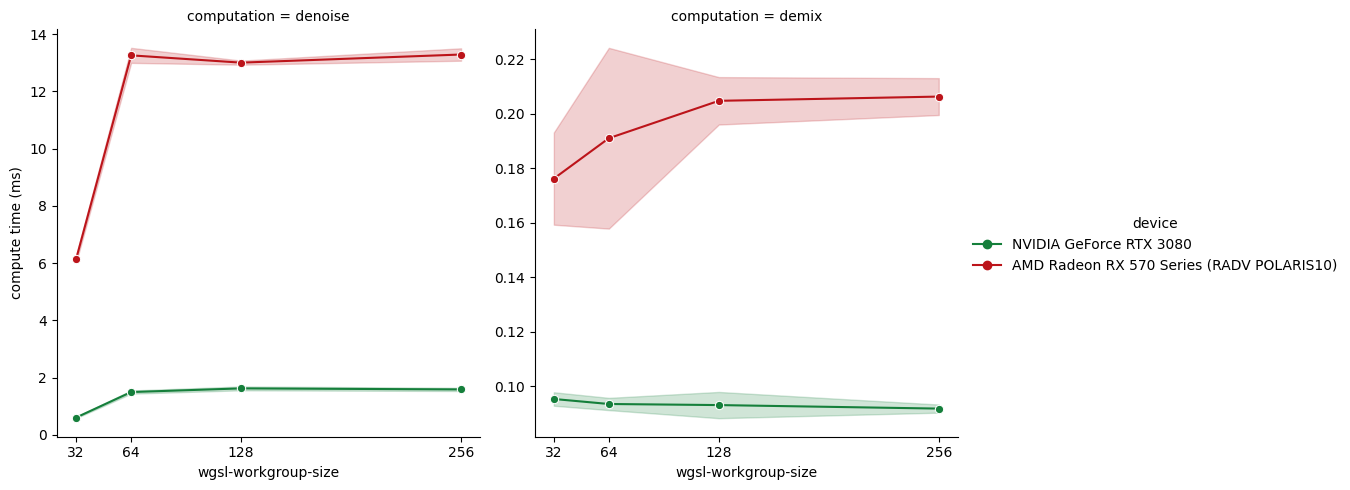

In [4]:
d1 = df[(df.backend == "wgsl") & (df.kernel == "scalar") & ((df.device == "NVIDIA GeForce RTX 3080") | (df.device == "AMD Radeon RX 570 Series (RADV POLARIS10)"))]
palette = {
    d: (
        sns.color_palette("Reds", 4)[3]
        if d.startswith("AMD")
        else sns.color_palette("Greens", 4)[3]
    )
    for d in d1["device"].unique()
}
sizes = sorted(d1["wgsl-workgroup-size"].unique())

g = sns.relplot(
    d1,
    kind="line",
    x="wgsl-workgroup-size",
    y="mean",
    hue="device",
    col="computation",
    col_order=["denoise", "demix"],
    palette=palette,
    marker="o",
    facet_kws={"sharey": False},
)

g.set_ylabels("compute time (ms)")

for ax, comp in zip(g.axes.flat, g.col_names):
    ax.set_xticks(sizes)


plt.show()


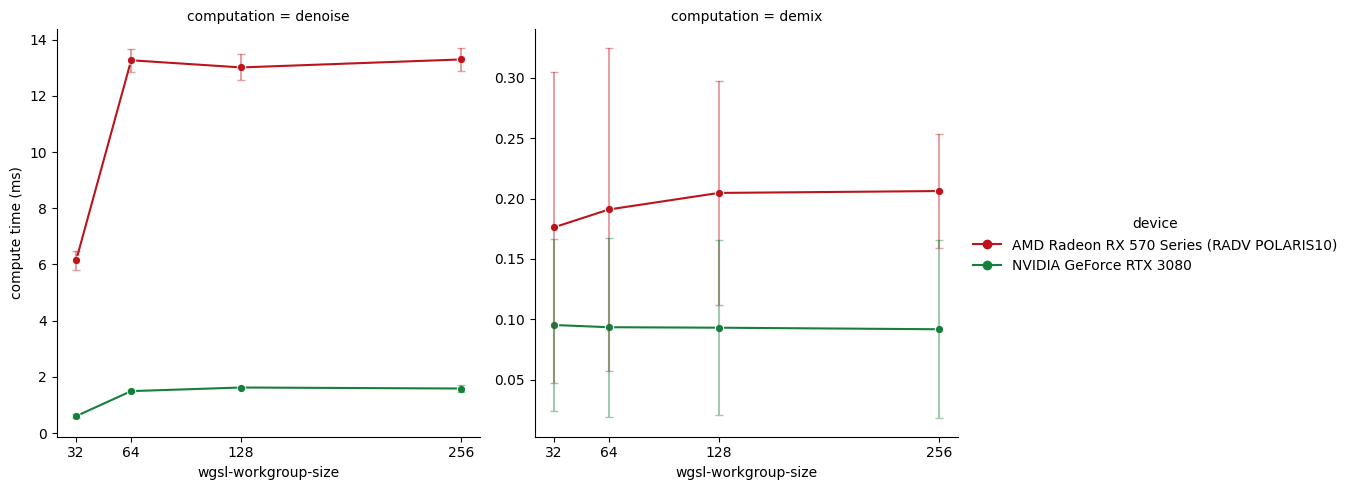

In [5]:
df = pd.read_csv("./benchmark_spmv.csv")

d1 = df[(df.backend == "wgsl") & (df.kernel == "scalar") & ((df.device == "NVIDIA GeForce RTX 3080") | (df.device == "AMD Radeon RX 570 Series (RADV POLARIS10)"))]
agg = d1.groupby(["device", "computation", "wgsl-workgroup-size"], as_index=False).agg(
    mean=("mean", "mean"), std=("std", "mean")
)
palette = {
    d: (
        sns.color_palette("Reds", 4)[3]
        if d.startswith("AMD")
        else sns.color_palette("Greens", 4)[3]
    )
    for d in agg["device"].unique()
}
sizes = sorted(agg["wgsl-workgroup-size"].unique())

g = sns.relplot(
    agg,
    kind="line",
    x="wgsl-workgroup-size",
    y="mean",
    hue="device",
    col="computation",
    col_order=["denoise", "demix"],
    marker="o",
    palette=palette,
    errorbar=None,
    facet_kws={"sharey": False},
)
g.set_ylabels("compute time (ms)")

for ax, comp in zip(g.axes.flat, g.col_names):
    ax.set_xticks(sizes)
    sub = agg[agg.computation == comp]
    for _, r in sub.iterrows():
        ax.errorbar(
            x=r["wgsl-workgroup-size"],
            y=r["mean"],
            yerr=r["std"],
            fmt="none",
            color=palette[r["device"]],
            alpha=0.4,
            capsize=3,
        )
plt.show()


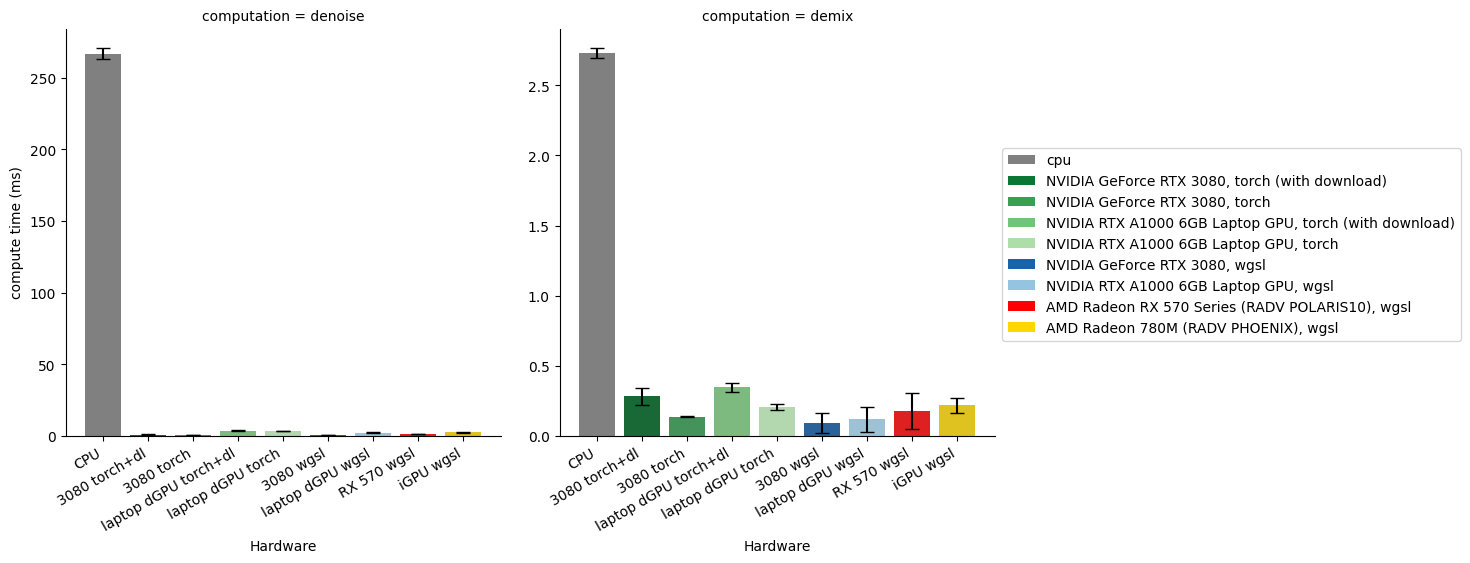

In [18]:
df = pd.read_csv("./benchmark_spmv.csv")

def make_label(row):                            
  dev = row["device"]
  dl = str(dev).lower()                                                                                                                                 
  backend = row["backend"]
                                                                                                                                                        
  if backend == "cpu" or "cpu" in dl:                                                                                                                   
      return "CPU"
                                                                                                                                                        
  if backend == "torch":
      if "3080" in dev:
          return "3080 torch+dl" if row["torch-download"] == True else "3080 torch"
      if "a1000" in dl or "laptop" in dl:
          return (                                                                                                                                      
              "laptop dGPU torch+dl"
              if row["torch-download"] == True                                                                                                          
              else "laptop dGPU torch"
          )                                                                                                                                             
      return None
                                                                                                                                                        
  if backend == "wgsl" and row["wgsl-workgroup-size"] == 32:
      target_kernel = "vector" if row["computation"] == "denoise" else "scalar"
      if row["kernel"] != target_kernel:                                                                                                                
          return None
      if "3080" in dev:                                                                                                                                 
          return "3080 wgsl"
      if "a1000" in dl or "laptop" in dl:
          return "laptop dGPU wgsl"                                                                                                                     
      if "rx 570" in dl:
          return "RX 570 wgsl"                                                                                                                          
      if "780m" in dl:
          return "iGPU wgsl"                                                                                                                            

  return None                                                                                                                                           


df["label"] = df.apply(make_label, axis=1)

order = [
    "CPU",
    "3080 torch+dl",
    "3080 torch",
    "laptop dGPU torch+dl",
    "laptop dGPU torch",
    "3080 wgsl",
    "laptop dGPU wgsl",
    "RX 570 wgsl",
    "iGPU wgsl",
]

d2 = df[df["label"].isin(order)].copy()
agg = d2.groupby(["label", "computation"], as_index=False).agg(
    mean=("mean", "mean"), std=("std", "mean")
)

greens = sns.color_palette("Greens", 5)
blues = sns.color_palette("Blues", 4)
palette = {
    "CPU": "grey",
    "3080 torch+dl": greens[4],
    "3080 torch": greens[3],
    "laptop dGPU torch+dl": greens[2],
    "laptop dGPU torch": greens[1],
    "3080 wgsl": blues[3],
    "laptop dGPU wgsl": blues[1],
    "RX 570 wgsl": "red",
    "iGPU wgsl": "gold",
}

g = sns.catplot(
    agg,
    kind="bar",
    x="label",
    y="mean",
    hue="label",
    order=order,
    hue_order=order,
    palette=palette,
    col="computation",
    col_order=["denoise", "demix"],
    sharey=False,
    errorbar=None,
    dodge=False,
    legend=False,
)
g.set_ylabels("compute time (ms)")
g.set_xlabels("Hardware")


for ax, comp in zip(g.axes.flat, g.col_names):
    sub = agg[agg.computation == comp].set_index("label").reindex(order)
    for i, (_, row) in enumerate(sub.iterrows()):
        if pd.isna(row["mean"]):
            continue
        ax.errorbar(
            i,
            row["mean"],
            yerr=row["std"],
            fmt="none",
            color="black",
            capsize=5,
            linewidth=1.5,
            zorder=10,
        )
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

import matplotlib.patches as mpatches                                                                                                                     
   
def full_legend(label):                                                                                                                                   
    rows = d2[d2["label"] == label]
    full_dev = rows["device"].iloc[0] if not rows.empty else label                                                                                        
    if "torch+dl" in label:
      return f"{full_dev}, torch (with download)"                                                                                                       
    if "torch" in label:                                                                                                                                  
      return f"{full_dev}, torch"
    if "wgsl" in label:                                                                                                                                   
      return f"{full_dev}, wgsl"
    return full_dev                                                                                                                                       

handles = [                                                                                                                                               
  mpatches.Patch(facecolor=palette[label], label=full_legend(label))
  for label in order
]
g.figure.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5))
g.figure.subplots_adjust(right=1.0)

plt.show()


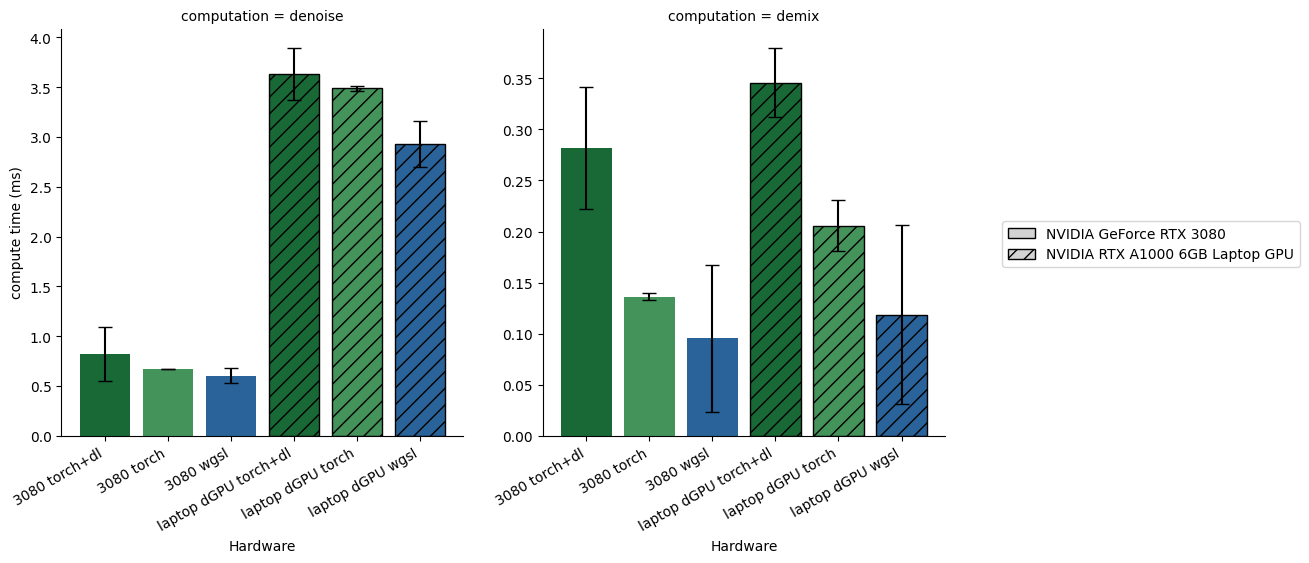

In [7]:
df = pd.read_csv("./benchmark_spmv.csv")

DESKTOP = "NVIDIA GeForce RTX 3080"
LAPTOP = "NVIDIA RTX A1000 6GB Laptop GPU"

nvidia = df["device"].str.contains("3080|A1000|Laptop", na=False)
torch_mask = nvidia & (df.backend == "torch")
wgsl_mask = (
    nvidia
    & (df.backend == "wgsl")
    & (df["wgsl-workgroup-size"] == 32)
    & (df.kernel == "scalar")
)
d2 = df[torch_mask | wgsl_mask].copy()


def make_label(row):
    prefix = "3080" if "3080" in row["device"] else "laptop dGPU"
    if row["backend"] == "torch":
        return (
            f"{prefix} torch+dl" if row["torch-download"] == True else f"{prefix} torch"
        )
    return f"{prefix} wgsl"


d2["label"] = d2.apply(make_label, axis=1)

order = [
    "3080 torch+dl",
    "3080 torch",
    "3080 wgsl",
    "laptop dGPU torch+dl",
    "laptop dGPU torch",
    "laptop dGPU wgsl",
]

agg = d2.groupby(["label", "computation"], as_index=False).agg(
    mean=("mean", "mean"), std=("std", "mean")
)

greens = sns.color_palette("Greens", 5)
blues = sns.color_palette("Blues", 4)
palette = {
    "3080 torch+dl": greens[4],
    "3080 torch": greens[3],
    "3080 wgsl": blues[3],
    "laptop dGPU torch+dl": greens[4],  # same as 3080 torch+dl, distinguished by hatch
    "laptop dGPU torch": greens[3],
    "laptop dGPU wgsl": blues[3],
}

g = sns.catplot(
    agg,
    kind="bar",
    x="label",
    y="mean",
    hue="label",
    order=order,
    hue_order=order,
    palette=palette,
    col="computation",
    col_order=["denoise", "demix"],
    sharey=False,
    errorbar=None,
    dodge=False,
    legend=False,
)
g.set_ylabels("compute time (ms)")
g.set_xlabels("Hardware")

for ax, comp in zip(g.axes.flat, g.col_names):
    sub = agg[agg.computation == comp].set_index("label").reindex(order)
    for i, ((label, row), patch) in enumerate(zip(sub.iterrows(), ax.patches)):
        if "laptop" in label:
            patch.set_hatch("//")
            patch.set_edgecolor("black")
        if not pd.isna(row["mean"]):
            ax.errorbar(
                i,
                row["mean"],
                yerr=row["std"],
                fmt="none",
                color="black",
                capsize=5,
                linewidth=1.5,
                zorder=10,
            )
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

handles = [
    mpatches.Patch(facecolor="lightgrey", edgecolor="black", label=DESKTOP),
    mpatches.Patch(facecolor="lightgrey", edgecolor="black", hatch="//", label=LAPTOP),
]
g.figure.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
)
g.figure.subplots_adjust(right=0.95)
plt.show()


/tmp/ipykernel_1253265/3393692000.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_1253265/3393692000.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


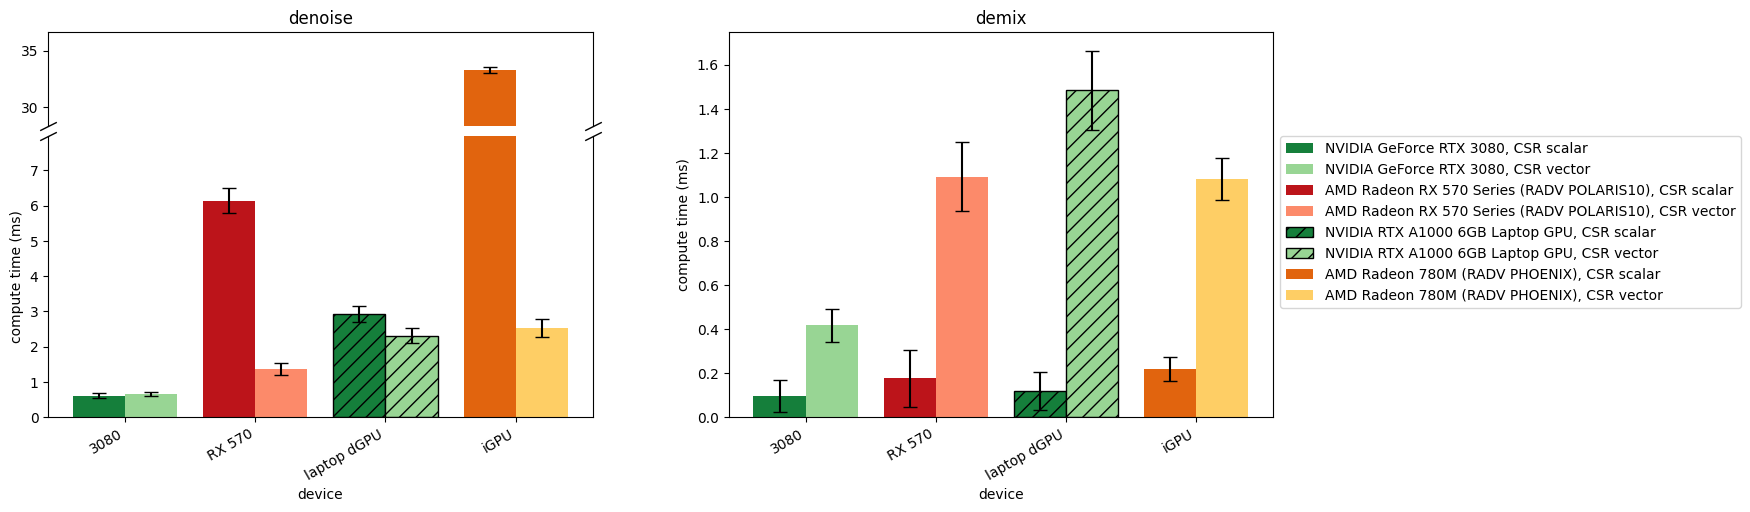

In [8]:
df = pd.read_csv("./benchmark_spmv.csv")

df = pd.read_csv("./benchmark_spmv.csv")

d3 = df[(df.backend == "wgsl") & (df["wgsl-workgroup-size"] == 32)]
agg = d3.groupby(["device", "computation", "kernel"], as_index=False).agg(
    mean=("mean", "mean"), std=("std", "mean")
)

kernel_order = ["scalar", "vector"]
device_order = [
    "NVIDIA GeForce RTX 3080",
    "AMD Radeon RX 570 Series (RADV POLARIS10)",
    "NVIDIA RTX A1000 6GB Laptop GPU",
    "AMD Radeon 780M (RADV PHOENIX)",
]

device_small_names = ["Nvidia RTX 3080", "AMD RX 570", "Nvidia laptop dGPU", "AMD laptop iGPU"]


def is_laptop(device):
    return "Laptop" in device or "A1000" in device


def is_igpu(device):
    return "780M" in device


def shade(device, kernel):
    if is_igpu(device):
        return sns.color_palette("YlOrBr", 5)[3 if kernel == "scalar" else 1]
    if device.startswith("AMD"):
        return sns.color_palette("Reds", 4)[3 if kernel == "scalar" else 1]
    return sns.color_palette("Greens", 4)[3 if kernel == "scalar" else 1]


def x_label(device):
    if is_igpu(device):
        return "iGPU"
    if is_laptop(device):
        return "laptop dGPU"
    if "3080" in device:
        return "3080"
    return "RX 570"


denoise = agg[agg.computation == "denoise"]
demix = agg[agg.computation == "demix"]

fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 3], hspace=0.05, wspace=0.25)
ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_dem = fig.add_subplot(gs[:, 1])


def style_bars(ax, sub):
    sns.barplot(
        sub,
        x="device",
        y="mean",
        hue="kernel",
        hue_order=kernel_order,
        order=device_order,
        ax=ax,
        errorbar=None,
        legend=False,
    )
    for ki, container in enumerate(list(ax.containers)):
        kernel = kernel_order[ki]
        for di, bar in enumerate(container):
            device = device_order[di]
            r = sub[(sub.device == device) & (sub.kernel == kernel)].iloc[0]
            bar.set_facecolor(shade(device, kernel))
            if is_laptop(device):
                bar.set_hatch("//")
                bar.set_edgecolor("black")
            x = bar.get_x() + bar.get_width() / 2
            ax.errorbar(
                x,
                r["mean"],
                yerr=r["std"],
                fmt="none",
                color="black",
                capsize=5,
                linewidth=1.5,
                zorder=10,
            )


style_bars(ax_top, denoise)
style_bars(ax_bot, denoise)
style_bars(ax_dem, demix)

# break point: iGPU scalar lives on ax_top, everything else on ax_bot
igpu_scalar = denoise[
    denoise.device.str.contains("780M") & (denoise.kernel == "scalar")
]["mean"].iloc[0]
others_max = denoise[
    ~(denoise.device.str.contains("780M") & (denoise.kernel == "scalar"))
]["mean"].max()
ax_bot.set_ylim(0, others_max * 1.3)
ax_top.set_ylim(igpu_scalar * 0.85, igpu_scalar * 1.1)

ax_top.spines.bottom.set_visible(False)
ax_bot.spines.top.set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)
ax_top.set_xlabel("")
d = 0.5
kw = dict(
    marker=[(-1, -d), (1, d)],
    markersize=12,
    linestyle="none",
    color="k",
    mec="k",
    mew=1,
    clip_on=False,
)
ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **kw)
ax_bot.plot([0, 1], [1, 1], transform=ax_bot.transAxes, **kw)

for ax in (ax_bot, ax_dem):
    ax.set_xticklabels(
        [x_label(t.get_text()) for t in ax.get_xticklabels()], rotation=30, ha="right"
    )
ax_top.set_title("denoise")
ax_dem.set_title("demix")
ax_dem.set_ylabel("compute time (ms)")
ax_bot.set_ylabel("compute time (ms)")
ax_top.set_ylabel("")

handles = []
for d_ in device_order:
    laptop = is_laptop(d_)
    for k in kernel_order:
        kwargs = dict(facecolor=shade(d_, k), label=f"{d_}, CSR {k}")
        if laptop:
            kwargs["hatch"] = "//"
            kwargs["edgecolor"] = "black"
        handles.append(mpatches.Patch(**kwargs))
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.subplots_adjust(right=1)
plt.show()